# Epstein Files Analysis

For the purpose of this project, I will be restricting my data purely to email documents.

## Identifying Emails

In [1]:
import re
import glob
from collections import defaultdict
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_FILES = glob.glob("../docs/TEXT/**/*.txt")

### Email Header Validation

In [3]:
REQUIRED_HEADERS = ["From:", "To:", "Sent:"]

'''
Checks if a given document is an email by checking for required headers

scan_limit used to reduce the # of lines to search for headers
'''
def isDocEmail(text: list[str], scan_limit: int = 20):
    reduced_text = text[:scan_limit]
    return all(
        any(line.strip().startswith(header) for line in reduced_text)
        for header in REQUIRED_HEADERS
    )

### Labeling Email Documents

In [4]:
EMAIL_DOCS = set()

'''
From the global DATA_FILES, find documents that are emails

Email documents are any document that contain the REQUIRED_HEADERS
'''
def findEmails():
    for file in DATA_FILES:
        with open(file, "rt", encoding="utf8") as f:
            text = f.readlines()

            if (isDocEmail(text)):
                EMAIL_DOCS.add(file)

findEmails()

### Extracting Email information

In [19]:
OPTIONAL_HEADERS = ["Subject:", "Importance:", "Attachments:"]

'''
Given a filepath to an email document, parse the email and
extract headers + content
'''
def parseEmail(filepath: str) -> defaultdict:
    with open(filepath, "rt", encoding="utf-8") as f:
        text : list[str] = f.readlines()

    data = defaultdict(str)
    last_header_loc = 0

    # Keep track of seen headers
    # Email chains wont overwrite top most header information
    seen = {h : False for h in REQUIRED_HEADERS + OPTIONAL_HEADERS}

    for i, line in enumerate(text):
        strp_line = line.strip()

        # Get all header information
        for header in REQUIRED_HEADERS + OPTIONAL_HEADERS:
            if (strp_line.startswith(header) and (not seen[header])):
                data[header[:-1]] = strp_line.removeprefix(header).strip()
                last_header_loc = max(last_header_loc, i)
                seen[header] = True
        
        # If we've seen all possible header information, stop
        if all(v for v in seen.values()):
            break
    
    body = "".join(text[last_header_loc + 1:]).strip()

    data["filename"] = filepath.split("\\")[-1]
    data["filepath"] = filepath
    data["body"] = body

    return data

### Parse Emails Into Dataframe

In [20]:
COLS = ["filename", "filepath", "body"].extend(REQUIRED_HEADERS + OPTIONAL_HEADERS)

parsed_emails = []

for doc in EMAIL_DOCS:
    data : dict = dict(parseEmail(doc))

    parsed_emails.append(data)

emails = pd.DataFrame(parsed_emails, columns=COLS)

In [9]:
# emails.to_parquet("parsed_emails.parquet")
emails

,From,Sent,To,Subject,Importance,filename,filepath,body,Attachments
0,"Weingarten, Reid",11/2/2017 6:05:42 PM,jeffrey E. [jeeyacation@gmail.com],Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_030666.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_030666.txt,Yep...order rod to fire him...rod would refuse...,NaN
1,Lisa New,10/5/2013 5:59:23 PM,Jeffrey Epstein [jeeyacation@gmail.com],Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_027035.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_027035.txt,Absolutely. 23rd is great. I teach my seminar ...,NaN
2,Robert Trivers_____________________________,2/9/2018 1:35:43 AM,Jeffrey Epstein [jeevacation@gmail.com],NaN,High,../docs/TEXT/001/HOUSE_OVERSIGHT_029447.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_029447.txt,Three short pieces that might amuse you (still...,French Chauvinism.docx; President Obama and Se...
3,,,,,High,../docs/TEXT/001/HOUSE_OVERSIGHT_022272.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_022272.txt,thanks 4 hours for a quote in a normally fast ...,
4,Robert Kuhn,1/1/2018 10:36:46 PM,jeffrey E. [jeeyacation@gmail.com],Fwd: Kuhn - Breakthroughs (and Trump),High,../docs/TEXT/001/HOUSE_OVERSIGHT_029150.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_029150.txt,Begin forwarded message: \nFrom: Robert Kuhn <...,NaN
...,...,...,...,...,...,...,...,...,...
2142,Jeffrey Epstein [jeeyacation@gmail.com],4/6/2011 10:15:22 PM,Lawrence Krauss,Re: Statement in the Daily Beast?,NaN,../docs/TEXT/001/HOUSE_OVERSIGHT_031022.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_031022.txt,"no it was appreciated. thanks \nOn Wed, Apr 6,...",NaN
2143,jeffrey E. [jeeyacation@gmail.com],3/31/2016 10:23:07 AM,Richard Kahn,Re: bad,NaN,../docs/TEXT/001/HOUSE_OVERSIGHT_026381.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_026381.txt,im told people think it is done on purpose so ...,NaN
2144,jeffrey E. [jeeyacation@gmail.com],5/25/2016 11:16:19 AM,Michael Wolff,Re: Trump,High,../docs/TEXT/001/HOUSE_OVERSIGHT_029272.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_029272.txt,maybe you can ask why bernie nussbaum got vinc...,NaN
2145,Multiple Senders [Multiple Senders],4/5/2019 11:06:20 AM,jeevacation; live:linkspirit,live:linkspirit -- 2019/04/05,NaN,../docs/TEXT/002/HOUSE_OVERSIGHT_032210.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032210.txt,jeevacation \n04/05/2019 10:06:20 AM \nwhich f...,NaN


# Cleaning Data

Now that the data has been parsed, we have to clean it.

For example, dates are in multiple formats. Info has been redacted, so it is missing. etc.

### Consistent Case

In [21]:
emails.columns  # I messed up, column names are mixed case

def cleanColumnCase():
    emails.columns = [col.strip().lower() for col in emails.columns]

    # Remove whitespace 
    for col in emails.columns:
        emails[col] = emails[col].astype(str).str.strip()

emails.columns

Index(['From', 'Sent', 'To', 'Subject', 'Importance', 'filename', 'filepath',
       'body', 'Attachments'],
      dtype='object')

### Renaming Column Names

In [8]:
def renameColumns():
    emails.rename(columns={"from": "sender", 
                        "sent": "date_sent", 
                        "to": "receiver"},
                inplace=True)

emails.columns

Index(['From', 'Sent', 'To', 'Subject', 'Importance', 'filename', 'filepath',
       'body', 'Attachments'],
      dtype='object')

### Extracting Emails From Header

In [22]:
cleanColumnCase()
renameColumns()
# Stole this from Google
email_pattern = r"([a-zA-Z0-9._%+\-\s]+[\@|\©][a-zA-Z0-9.\-\s]+\.[a-zA-Z]{2,})" # .extract wanted the pattern surrounded in ()
sr_pattern = r"[a-zA-Z0-9._%+\-\s]+@[a-zA-Z0-9.\-\s]+\.[a-zA-Z]{2,}"

# Extracting emails
emails["sender_email"] = emails["sender"].str.extract(email_pattern, expand=False)
emails["receiver_email"] = emails["receiver"].str.extract(email_pattern, expand=False)

# Removing emails from original columns
emails["sender"] = emails["sender"].str.replace(sr_pattern, "", regex=True).str.strip()
emails["receiver"] = emails["receiver"].str.replace(sr_pattern, "", regex=True).str.strip()

# Cleanup leftover (Note: This still doesn't take care of everything)
emails["sender"] = emails["sender"].str.replace(r"[\[\]]|[\<\>]", "", regex=True).str.strip()
emails["receiver"] = emails["receiver"].str.replace(r"[\[\]]|[\<\>]|[\(\)]", "", regex=True).str.strip()

### Cleaning Epstein Name Variations

In [171]:
candidates = set(
    [x for x in emails["sender"].unique() if isinstance(x, str) and ("jee" in x or "jeff" in x)] 
    + [x for x in emails["receiver"].unique() if isinstance(x, str) and ("jee" in x or "jeff" in x)]
)

sorted(candidates)

["'jeevacation©gmail.com' jeevacation©gmail.com;",
 "'jeffrey E.'",
 "'jeffrey E.' ; 'Philip Kafka'",
 'E. jeffrey',
 'Jeffrey Epstein jeevacation©gmail.com',
 'Jeffrey Epstein jeevacation©gmail.com;',
 'Jeffrey Epstein jeevacation©grnail.com',
 'Steven Pfeiffer jeffrey E.',
 'jeevacation',
 'jeevacation; live:linkspirit',
 'jeff epstein',
 'jeffrey E.',
 'jeffrey E.  mailto:',
 'jeffrey E. ;',
 'jeffrey E. ; Alan M. Dershowitz',
 'jeffrey E. ; Darren Indyke',
 'jeffrey E. ; Jack Lang',
 'jeffrey E. ; Lang, Caroline',
 'jeffrey E. ; Peggy Siegal',
 'jeffrey E. ; Rich Kahn',
 'jeffrey E. ; Richard Kah ___________________________________',
 'jeffrey E. ; Richard Kahn',
 'jeffrey E. jeeyacation@gmail,com',
 'jeffrey E. peevacationPgmail.coml',
 'jeffrey epstein',
 'jeffrey epstein usa',
 'lawkrauss; jeevacation']

In [15]:
emails["receiver_email"].unique()

array(['jeeyacation@gmail.com', 'jeevacation@gmail.com', nan,
       'gmax1@ellmax.com', 'jeffreyepsteinpeeyacation@gmail.com',
       'jjepjeevacation@gmail.com', 'jeffreyepsteinjeevacation@gmail.com',
       'jeffreye.peeyacation@gmail.com', 'owlmgw@att.net',
       'eeyacation@gmail.com', 'jeeproject@yahoo.com',
       'jdeevacation@gmail.com', 'darrenindykejeeyacation@gmail.com'],
      dtype=object)

### Cleaning Emails

In [23]:
def clean_email(text: str):
    if (not isinstance(text, str)):
        return text
    
    text = text.strip().lower()
    
    # "mailto" is an HTML action that opens the user's default email client when clicked
    text = text.replace("mailto:", "")

    # Remove whitespace from emails
    text = text.replace(" ", "")

    # Replace © with @
    text = text.replace("©", "@")

    # Replace common misspellings of "gmail"
    text = text.replace("@grnail", "@gmail")
    text = text.replace("@gmaii", "@gmail")
    text = text.replace("@mail", "@gmail")
    

    # Replace common mispellings of ".com"
    text = text.replace(".comi", ".com")
    text = text.replace(".corn", ".com")

    return text.strip()
    
emails["sender_email"] = emails["sender_email"].apply(clean_email)
emails["receiver_email"] = emails["receiver_email"].apply(clean_email)

emails

,sender,date_sent,receiver,subject,importance,filename,filepath,body,attachments,sender_email,receiver_email
0,Richard Kahn,11/14/2016 3:04:29 PM,jeffrey E.,aapl,High,../docs/TEXT/002/HOUSE_OVERSIGHT_033192.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_033192.txt,http://www.cnbc.com/2016/11/14/apple-iphones-c...,nan,NaN,jeeyacation@gmail.com
1,anasalrasheed,11/6/2017 9:07:51 PM,jeffrey E.,Re:,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032643.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032643.txt,this was just tweeted by famous saudi oppositi...,nan,NaN,jeeyacation@gmail.com
2,,1/15/2017 1:49:11 PM,jeffrey E.,Re:,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032436.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032436.txt,People are just back and the activity really s...,nan,NaN,jeeyacation@gmail.com
3,,12/22/2017 12:23:04 PM,jeffrey E.,Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_026237.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_026237.txt,very well .. keep us posted about your gee tri...,nan,NaN,jeeyacation@gmail.com
4,Thorbjon Jagland,4/16/2017 3:23:31 PM,jeffrey E.,Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_026673.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_026673.txt,You should feel well for having done so much f...,nan,NaN,jeeyacation@gmail.com
...,...,...,...,...,...,...,...,...,...,...,...
2142,Nicholas Ribis,5/13/2016 12:31:13 AM,Jeffrey Epstein,Fw: Washington Post Article,High,../docs/TEXT/002/HOUSE_OVERSIGHT_033295.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_033295.txt,Sent from my BlackBerry 10 smartphone. \nThoug...,nan,NaN,jeeyacation@gmail.com
2143,Linda Stone__________________________,11/13/2016 6:34:38 PM,jeffrey E.,Re: My sister's perspective from Europe,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032363.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032363.txt,Putin? NATO? Those were the points my sister r...,nan,NaN,jeevacation@gmail.com
2144,"Weingarten, Reid",11/2/2017 6:05:42 PM,jeffrey E.,Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_030666.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_030666.txt,Yep...order rod to fire him...rod would refuse...,nan,NaN,jeeyacation@gmail.com
2145,Kathy Ruemmler,1/21/2016 2:42:21 AM,jeffrey E.,Re: Meet?,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032233.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032233.txt,Privileged - Redacted \nSent from my iPhone \n...,nan,NaN,jeeyacation@gmail.com


## Who Was Epstein Emailing?

In [62]:
query = f"""
    SELECT
        receiver
    FROM
        emails
"""
duckdb.query(query).df()

,receiver
0,jeffrey E.
1,Jeffrey Epstein
2,Jeffrey Epstein
3,
4,jeffrey E.
...,...
2142,Lawrence Krauss
2143,Richard Kahn
2144,Michael Wolff
2145,jeevacation; live:linkspirit


In [103]:
target = "Michael"
query = f"""
    SELECT
        DISTINCT receiver
    FROM
        emails
    WHERE
        receiver ILIKE '%{target}%'
"""
duckdb.query(query).df()

,receiver
0,Michael Wolff
1,Michael Woli
2,Michael J. Pike
3,Michael S. Sitrick
4,DANNY GOLDBERG ; Sam/Walli Leff Michael Simmons
5,Michael S. Buchholtz


In [24]:
## Let's first fix some names
NAME_MAPPING = {
    "Jeffrey Epstein": ["jeffrey E.", "jeffrey E. peevacationPgmail.coml", "'jeffrey E.'", "Jeffrey", "effrey E. jeeyacation@gmail,com",
                        "Jeffrey Epstein ; Jeffrey Epstein", "Jeffrey", "Jeffrey Epstein  ;", "jeffrey E. ;", ],
    "Michael Wolff": ["Michael Wolff___________________________________", "Michael Wolff _________________________________1",
                      "Michael Wolff________________________________", "Michael Wolff__________________________________",
                      "Michael Woli"],
    "Thomas Landon": ["Thomas Jr., Landon___________________________", "Thomas Jr., Landon'", "Landon Thomas Jr",
                      "Landon Thomas Jr.", "Thomas Jr., Landon________________", "Landon Thomas", "Thomas Jr., Landon"],
    "Kathy Ruemmler": ["Kathy Ruemmlerl", "Kathy Ruemmler ______________________________", "Kathy Ruemmler _______________________________",
                       "Kathy Ruemmler I", "Kathy", "Kathy Ruemmler__________________", "Kathy Ruemmler f"],
    "Richard Kahn": ["Richard Kahn_________________________________", "Richard Kahn______________________________", 
                     "Richard Kahn_______________________"],
    "Ghislaine Maxwell": ["Gmax", "G Maxwell"]
}

REVERSED_NAME_MAPPING = {x: k for k,v in NAME_MAPPING.items() for x in v}

def applyNameMapping(name: str):
    if (not isinstance(name, str)):
        return None
    
    name = name.strip()

    try:
        return REVERSED_NAME_MAPPING[name]
    except KeyError:
        return name
emails["sender"] = emails["sender"].apply(applyNameMapping)
emails["receiver"] = emails["receiver"].apply(applyNameMapping)

In [12]:
# emails["receiver_list"] = emails["receiver"].str.split(":")
# receiver_exploded = emails.explode("receiver_list")
# receiver_exploded["receiver_list"] = receiver_exploded["receiver_list"].str.strip()
# receiver_exploded = receiver_exploded[receiver_exploded["receiver_list"] != ""]

candidate_emails = [e for e in emails["sender_email"].unique() if isinstance(e, str) and ("jee" in e)]

epstein_alias = [p for p in emails["sender"].unique() if isinstance(p, str) and ("jef" in p.lower() or "epst" in p.lower() or "jee" in p.lower())]

epstein_receivers = emails[emails["sender"].isin(epstein_alias)]["receiver"]

epstein_receivers = epstein_receivers.dropna().to_frame()

/var/folders/ml/fzp4hsz17tb4xtns43992l0w0000gn/T/ipykernel_55970/4027095566.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


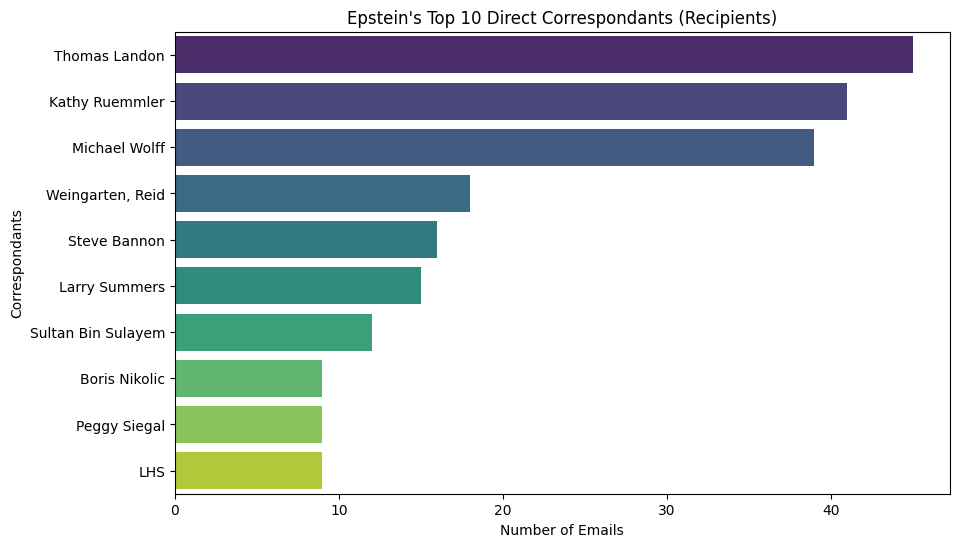

,receiver,freq
0,Thomas Landon,45
1,Kathy Ruemmler,41
2,Michael Wolff,39
3,"Weingarten, Reid",18
4,Steve Bannon,16
5,Larry Summers,15
6,Sultan Bin Sulayem,12
7,Boris Nikolic,9
8,Peggy Siegal,9
9,LHS,9


In [13]:
query = f"""
    SELECT
        receiver,
        COUNT(*) AS freq
    FROM
        epstein_receivers
    WHERE
        length(receiver) > 0
    GROUP BY
        receiver
    ORDER BY
        freq DESC
    LIMIT 10
"""
epstein_contacts = duckdb.query(query).df()

plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x=epstein_contacts["freq"],
    y=epstein_contacts["receiver"],
    palette="viridis"
)

plt.title("Epstein's Top 10 Direct Correspondants (Recipients)")
plt.xlabel("Number of Emails")
plt.ylabel("Correspondants")
plt.show()

epstein_contacts

## Who Was Emailing Epstein?

In [14]:
epstein_alias = [p for p in emails["receiver"].unique() if isinstance(p, str) and ("je" in p.lower() or "eps" in p.lower())]

epstein_senders = emails[emails["receiver"].isin(epstein_alias)]["sender"]

epstein_senders = epstein_senders.dropna().to_frame()

/var/folders/ml/fzp4hsz17tb4xtns43992l0w0000gn/T/ipykernel_55970/2700905116.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


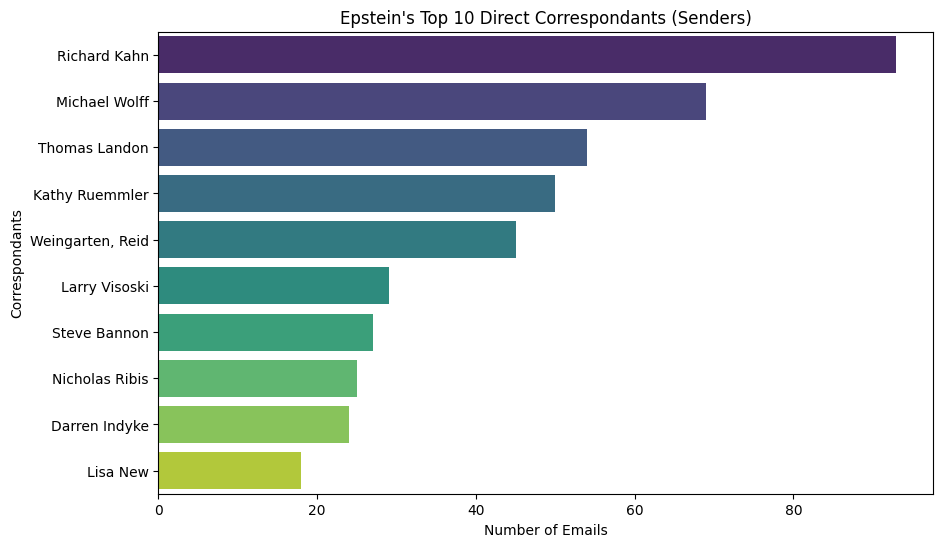

In [15]:
query = f"""
    SELECT
        sender,
        COUNT(*) AS freq
    FROM
        epstein_senders
    WHERE
        length(sender) > 1
    GROUP BY
        sender
    ORDER BY
        freq DESC
    LIMIT 10
"""

epstein_contacts = duckdb.query(query).df()

plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x=epstein_contacts["freq"],
    y=epstein_contacts["sender"],
    palette="viridis"
)

plt.title("Epstein's Top 10 Direct Correspondants (Senders)")
plt.xlabel("Number of Emails")
plt.ylabel("Correspondants")
plt.show()

## Michael Wolff

In [42]:
target = "Michael Wolff"
emails[(emails["sender"] == target) | (emails["receiver"] == target)]["filename"]

15      ../docs/TEXT/001/HOUSE_OVERSIGHT_030689.txt
16      ../docs/TEXT/002/HOUSE_OVERSIGHT_032829.txt
18      ../docs/TEXT/001/HOUSE_OVERSIGHT_030789.txt
27      ../docs/TEXT/001/HOUSE_OVERSIGHT_030974.txt
61      ../docs/TEXT/002/HOUSE_OVERSIGHT_032239.txt
                           ...                     
2060    ../docs/TEXT/001/HOUSE_OVERSIGHT_031684.txt
2066    ../docs/TEXT/002/HOUSE_OVERSIGHT_032475.txt
2072    ../docs/TEXT/001/HOUSE_OVERSIGHT_030766.txt
2074    ../docs/TEXT/001/HOUSE_OVERSIGHT_026450.txt
2133    ../docs/TEXT/002/HOUSE_OVERSIGHT_032229.txt
Name: filename, Length: 139, dtype: object

In [26]:
emails["dt"] = pd.to_datetime(emails["date_sent"], errors="coerce")
emails["month"] = pd.to_datetime(emails["dt"].dt.to_period("M"), errors="coerce")

emails

/var/folders/ml/fzp4hsz17tb4xtns43992l0w0000gn/T/ipykernel_55970/738025596.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  emails["dt"] = pd.to_datetime(emails["date_sent"], errors="coerce")


,sender,date_sent,receiver,subject,importance,filename,filepath,body,attachments,sender_email,receiver_email,dt,month
0,Richard Kahn,11/14/2016 3:04:29 PM,Jeffrey Epstein,aapl,High,../docs/TEXT/002/HOUSE_OVERSIGHT_033192.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_033192.txt,http://www.cnbc.com/2016/11/14/apple-iphones-c...,nan,NaN,jeeyacation@gmail.com,2016-11-14 15:04:29,NaT
1,anasalrasheed,11/6/2017 9:07:51 PM,Jeffrey Epstein,Re:,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032643.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032643.txt,this was just tweeted by famous saudi oppositi...,nan,NaN,jeeyacation@gmail.com,2017-11-06 21:07:51,NaT
2,,1/15/2017 1:49:11 PM,Jeffrey Epstein,Re:,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032436.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032436.txt,People are just back and the activity really s...,nan,NaN,jeeyacation@gmail.com,2017-01-15 13:49:11,NaT
3,,12/22/2017 12:23:04 PM,Jeffrey Epstein,Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_026237.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_026237.txt,very well .. keep us posted about your gee tri...,nan,NaN,jeeyacation@gmail.com,2017-12-22 12:23:04,NaT
4,Thorbjon Jagland,4/16/2017 3:23:31 PM,Jeffrey Epstein,Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_026673.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_026673.txt,You should feel well for having done so much f...,nan,NaN,jeeyacation@gmail.com,2017-04-16 15:23:31,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2142,Nicholas Ribis,5/13/2016 12:31:13 AM,Jeffrey Epstein,Fw: Washington Post Article,High,../docs/TEXT/002/HOUSE_OVERSIGHT_033295.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_033295.txt,Sent from my BlackBerry 10 smartphone. \nThoug...,nan,NaN,jeeyacation@gmail.com,2016-05-13 00:31:13,NaT
2143,Linda Stone__________________________,11/13/2016 6:34:38 PM,Jeffrey Epstein,Re: My sister's perspective from Europe,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032363.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032363.txt,Putin? NATO? Those were the points my sister r...,nan,NaN,jeevacation@gmail.com,2016-11-13 18:34:38,NaT
2144,"Weingarten, Reid",11/2/2017 6:05:42 PM,Jeffrey Epstein,Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_030666.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_030666.txt,Yep...order rod to fire him...rod would refuse...,nan,NaN,jeeyacation@gmail.com,2017-11-02 18:05:42,NaT
2145,Kathy Ruemmler,1/21/2016 2:42:21 AM,Jeffrey Epstein,Re: Meet?,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032233.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032233.txt,Privileged - Redacted \nSent from my iPhone \n...,nan,NaN,jeeyacation@gmail.com,2016-01-21 02:42:21,NaT


In [ ]:
query=f"""
    SELECT
        receiver,
        CAST(dt AS DATE) AS date,
        COUNT(*) AS freq
    FROM
        emails
    WHERE
        length(emails.receiver) > 1 AND length(emails.sender) > 1
    GROUP BY
        receiver, dt
    ORDER BY
        receiver, dt ASC
"""

duckdb.query(query).df().to_csv("")

,receiver,dt,freq
0,'',2012-01-23,1
1,'',2012-10-16,1
2,'' ;,2011-03-08,1
3,'Jeffrey Epstein',2011-06-27,1
4,'Jeffrey Epstein',2011-08-07,1
...,...,...,...
1448,soon yi previn,2015-12-08,1
1449,soon yi previn,2016-05-04,1
1450,soon yi previn,2017-06-30,1
1451,• Darren Indyke,2013-05-13,1
